<a href="https://colab.research.google.com/github/01PrathamS/Stable_Diffusion_from_scratch/blob/main/notebooks/AE_vs_VAE_latent_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q matplotlib torchvision torch

In [3]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [10]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


Device: cpu


In [11]:

class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc_mu = nn.Linear(128, 2)
        self.fc_logvar = nn.Linear(128, 2)
        self.fc2 = nn.Linear(2, 128)
        self.fc3 = nn.Linear(128, 28*28)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h2 = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h2))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), z, mu, logvar


In [12]:

def loss_ae(output, x):
    return F.mse_loss(output, x)

def loss_vae(output, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(output, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

def train(model, optimizer, ae=False):
    model.train()
    for epoch in range(20):
        total_loss = 0
        for x, _ in train_loader:
            x = x.view(-1, 28*28).to(device)
            optimizer.zero_grad()
            if ae:
                output, z = model(x)
                loss = loss_ae(output, x)
            else:
                output, z, mu, logvar = model(x)
                loss = loss_vae(output, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.2f}")





In [13]:
import time

start_time = time.time()

ae = AE().to(device)
optimizer_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)
print("\nTraining Autoencoder...")
train(ae, optimizer_ae, ae=True)

print(f"Time Taken:{time.time() - start_time}")



Training Autoencoder...
Epoch 1, Loss: 0.06
Epoch 2, Loss: 0.05
Epoch 3, Loss: 0.05
Epoch 4, Loss: 0.05
Epoch 5, Loss: 0.05
Epoch 6, Loss: 0.05
Epoch 7, Loss: 0.05
Epoch 8, Loss: 0.05
Epoch 9, Loss: 0.04
Epoch 10, Loss: 0.04
Epoch 11, Loss: 0.04
Epoch 12, Loss: 0.04
Epoch 13, Loss: 0.04
Epoch 14, Loss: 0.04
Epoch 15, Loss: 0.04
Epoch 16, Loss: 0.04
Epoch 17, Loss: 0.04
Epoch 18, Loss: 0.04
Epoch 19, Loss: 0.04
Epoch 20, Loss: 0.04
Time Taken:257.8186628818512


In [14]:
star_time = time.time()

vae = VAE().to(device)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
print("\nTraining Variational Autoencoder...")
train(vae, optimizer_vae, ae=False)

print(f"Time Taken:{time.time() - start_time}")



Training Variational Autoencoder...
Epoch 1, Loss: 26363.58
Epoch 2, Loss: 22628.42
Epoch 3, Loss: 21790.04
Epoch 4, Loss: 21299.14
Epoch 5, Loss: 21003.74
Epoch 6, Loss: 20789.13
Epoch 7, Loss: 20620.11
Epoch 8, Loss: 20479.92
Epoch 9, Loss: 20363.62
Epoch 10, Loss: 20271.00
Epoch 11, Loss: 20198.75
Epoch 12, Loss: 20122.20
Epoch 13, Loss: 20062.78
Epoch 14, Loss: 20015.10
Epoch 15, Loss: 19963.85
Epoch 16, Loss: 19921.32
Epoch 17, Loss: 19877.41
Epoch 18, Loss: 19834.63
Epoch 19, Loss: 19805.49
Epoch 20, Loss: 19778.67
Time Taken:508.93989062309265


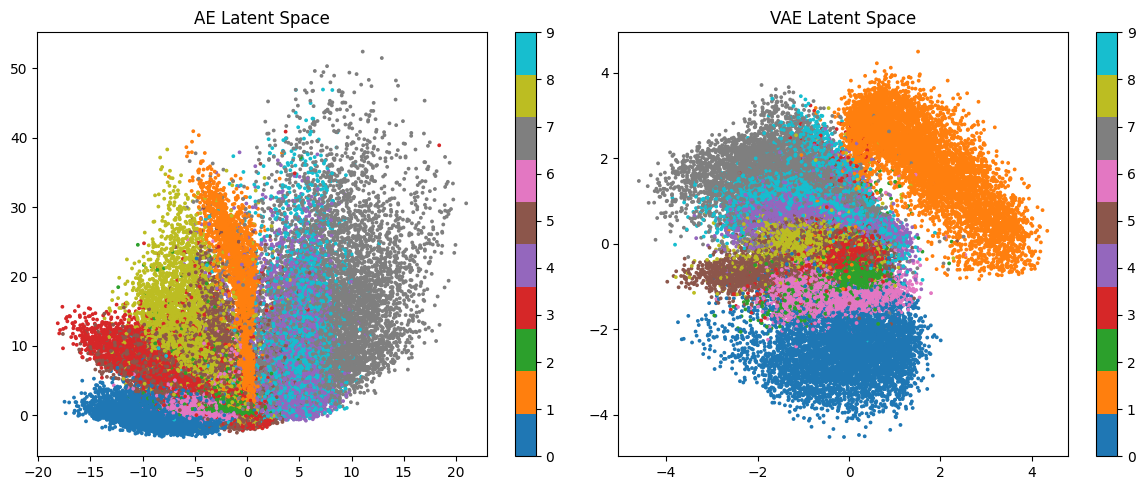

In [15]:

def get_latents(model, ae=True):
    zs, labels = [], []
    model.eval()
    with torch.no_grad():
        for x, y in train_loader:
            x = x.view(-1, 28*28).to(device)
            if ae:
                _, z = model(x)
            else:
                _, z, _, _ = model(x)
            zs.append(z.cpu())
            labels.append(y)
    return torch.cat(zs).numpy(), torch.cat(labels).numpy()

z_ae, labels_ae = get_latents(ae, ae=True)
z_vae, labels_vae = get_latents(vae, ae=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(z_ae[:, 0], z_ae[:, 1], c=labels_ae, cmap='tab10', s=3)
plt.title('AE Latent Space')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(z_vae[:, 0], z_vae[:, 1], c=labels_vae, cmap='tab10', s=3)
plt.title('VAE Latent Space')
plt.colorbar()
plt.tight_layout()
plt.show()

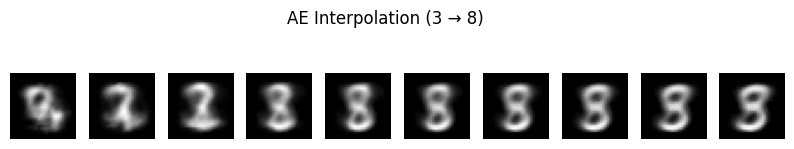

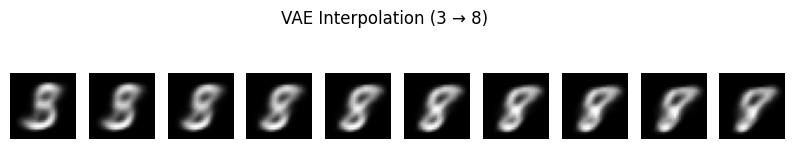

In [26]:
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

def get_digit_latent(model, digit, ae=True):
    for x, y in test_loader:
        idx = (y == digit).nonzero(as_tuple=True)[0]
        if len(idx) >= 1:
            x_digit = x[idx[0]].view(1, -1).to(device)
            if ae:
                z = model.encoder(x_digit)
            else:
                mu, logvar = model.encode(x_digit)
                z = mu
            return z
    return None


z1_ae = get_digit_latent(ae, 3, ae=True)
z2_ae = get_digit_latent(ae, 8, ae=True)
z1_vae = get_digit_latent(vae, 3, ae=False)
z2_vae = get_digit_latent(vae, 8, ae=False)

alphas = torch.linspace(0, 1, 10).unsqueeze(1).to(device)
z_interp_ae = (1 - alphas) * z1_ae + alphas * z2_ae
z_interp_vae = (1 - alphas) * z1_vae + alphas * z2_vae

with torch.no_grad():
    decoded_ae = ae.decoder(z_interp_ae).cpu()
    decoded_vae = vae.decode(z_interp_vae).cpu()

def plot_images(images, title):
    plt.figure(figsize=(10, 2))
    for i in range(len(images)):
        img = images[i].detach().cpu().numpy().reshape(28, 28)  # <-- reshape
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


plot_images(decoded_ae, "AE Interpolation (3 → 8)")
plot_images(decoded_vae, "VAE Interpolation (3 → 8)")
